# Single Tarso (Pastas) model for one time series

This notebook creates a minimal Pastas model (Tarso-style) using a random timeseries
`output_data/only_csv_wiertsema/time_series.csv` as the observed head.

Steps:
1. Find the repository root using relative paths.
2. Load the CSV and pick the first numeric column as the observed series.
3. Try to load a precipitation stress from `input_stressors/prec_station_249.csv` (if present), otherwise create a small synthetic stress.
4. Build a tiny Pastas model with a Gamma response and fit it.

Run the cells below in order.

In [1]:
# Cell 2: setup imports and repo discovery
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pastas as ps


warnings.filterwarnings('ignore')

# find repo root
repo_root = Path.cwd()
for candidate in [repo_root] + list(repo_root.parents):
    if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
        repo_root = candidate
        break
print('Repo root:', repo_root)

wiertsema_dir = repo_root / 'output_data' / 'only_csv_wiertsema'
fugro_dir = repo_root / 'output_data' / 'only_csv_fugro'    
singles_dir = repo_root / 'output_data' / 'only_csv_singles'
stressor_dir = repo_root / 'input_stressors'
out_fig = repo_root / 'output_data' / 'figures'
out_fig.mkdir(parents=True, exist_ok=True)

Repo root: d:\Users\jvanruitenbeek\data_validation


In [2]:
import pandas as pd
from pathlib import Path

# Name of the directory containing single well data
name_model = "BE0049BIK.xlsx - Sheet1"

# # # --- Load and clean the head data ---------------------------------------------
df_head = pd.read_csv(
    Path(singles_dir) / (name_model + ".csv"),
    index_col=0,
    parse_dates=True,
    encoding="utf-8-sig"
)

#--- Load and clean the head data ---------------------------------------------
# df_head = pd.read_csv(
#     Path(wiertsema_dir) / (name_model + ".csv"),
#     usecols=["Time","head"],
#     parse_dates=["Time"],
#     dayfirst=True,
#     index_col="Time",
#     encoding="utf-8-sig"
# )

# Take first numeric column and rename to 'head'
head = df_head.select_dtypes("number").iloc[:, 0].rename("head")

# Crop to first and last valid (non-NaN) data points
df_head = head.loc[head.first_valid_index(): head.last_valid_index()]


df_prec = pd.read_csv(Path(stressor_dir) / "prec_station_249_2020.csv",
                   index_col=0, parse_dates=True)["Precipitation"]

df_evap = pd.read_csv(Path(stressor_dir) / "evap_station_249_2020.csv",
                   index_col=0, parse_dates=True)["ET"]

df_evap_mak = pd.read_csv(Path(stressor_dir) / "knmi_berkhout_hourly_makkink.csv",
                   index_col=0, parse_dates=True)["ET"]

df_evap_hg = pd.read_csv(Path(stressor_dir) / "knmi_berkhout_hourly_hargreaves.csv",
                   index_col=0, parse_dates=True)["ET"]

df_evap_pm = pd.read_csv(Path(stressor_dir) / "knmi_berkhout_hourly_penman_monteith.csv",
                   index_col=0, parse_dates=True)["ET"]

df_prec_long = pd.read_csv(Path(stressor_dir) / "precipitation_long_clean.csv",
                   index_col=0, parse_dates=True)["precipitation"]

df_evap_long = pd.read_csv(Path(stressor_dir) / "evaporation_long_clean.csv",
                   index_col=0, parse_dates=True)["evaporation"]

In [3]:
def hourly_to_daily_sum(et_hourly: pd.Series) -> pd.Series:
    # Ensure datetime index + sorted
    et_hourly = et_hourly.copy()
    et_hourly.index = pd.to_datetime(et_hourly.index)
    et_hourly = et_hourly.sort_index()

    # Daily sum (calendar day)
    et_daily = et_hourly.resample("D").sum(min_count=1)

    # Optional: name
    et_daily.name = f"{et_hourly.name}_daily_sum" if et_hourly.name else "ET_daily_sum"
    return et_daily

In [4]:
df_evap_mak_daily = hourly_to_daily_sum(df_evap_mak)
df_evap_hg_daily  = hourly_to_daily_sum(df_evap_hg)
df_evap_pm_daily_mm  = hourly_to_daily_sum(df_evap_pm)
df_evap_pm_daily = df_evap_pm_daily_mm / 10.0  # convert mm to cm


In [5]:
# start_slice_date = "2024-02-15"
# end_slice_date = "2024-12-03"

# # Slicing the data 
# df_slice = df_head.loc[start_slice_date:end_slice_date]


# df_head = df_head / 100

# Modifying df_head to only include data between start_slice_date and end_slice_date
#df_slice.info()
df_head_daily = df_head.sort_index().resample("D").last()

#Converting values to NaN
#df_head_clean = df_head.where(df_head >= -450)

# Converting to m and plotting
#df_head_m = df_head_clean / 100
#df_head_m.plot()

<Axes: xlabel='Timestamp'>

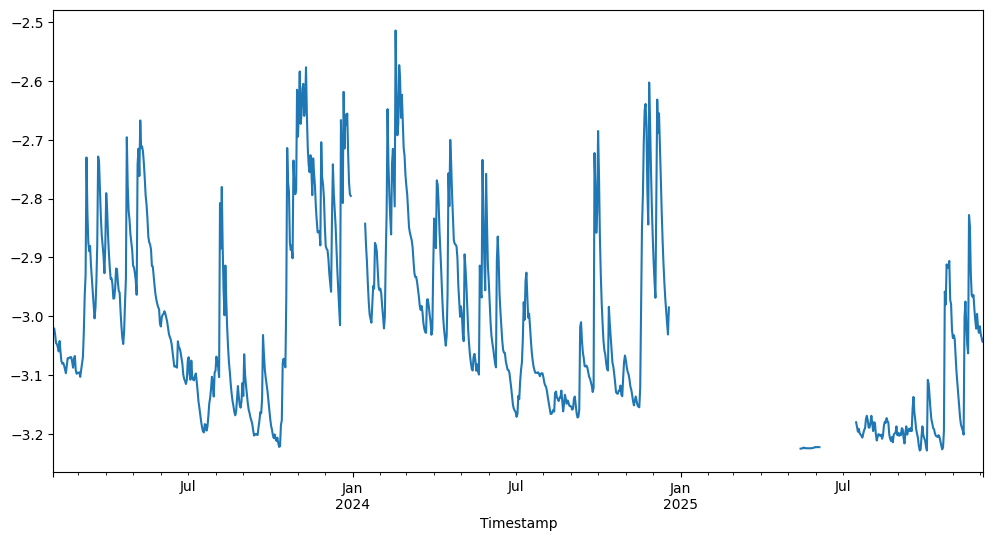

In [6]:
df_head_daily.plot(figsize=(12,6))

<class 'pandas.core.series.Series'>
DatetimeIndex: 2101 entries, 2020-01-01 to 2025-10-01
Series name: Precipitation
Non-Null Count  Dtype  
--------------  -----  
2101 non-null   float64
dtypes: float64(1)
memory usage: 32.8 KB


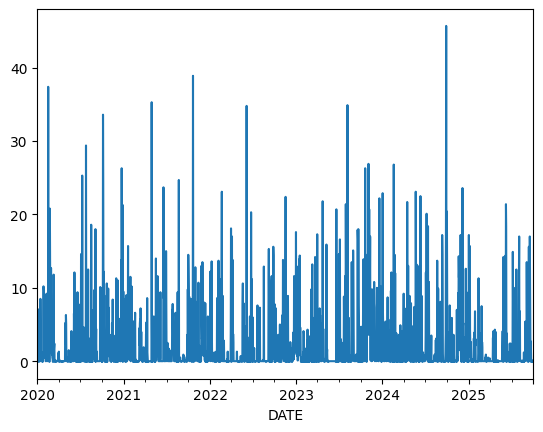

In [7]:
df_prec.plot()
df_prec.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 2101 entries, 2020-01-01 to 2025-10-01
Series name: ET
Non-Null Count  Dtype  
--------------  -----  
2101 non-null   float64
dtypes: float64(1)
memory usage: 32.8 KB


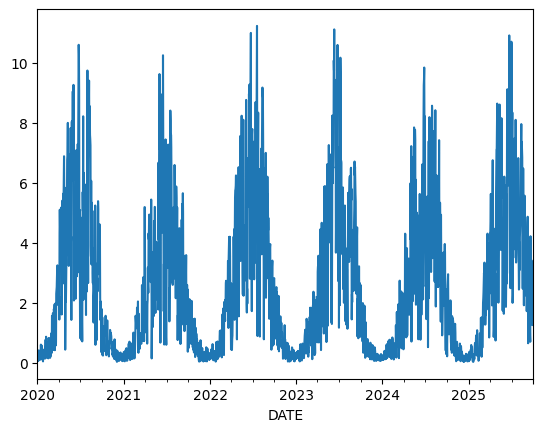

In [8]:
df_evap.plot()
df_evap.info()

In [9]:
import pandas as pd
import pastas as ps

# # --- Prepare series from your current variables --------------------------------
# # If df_head is a DataFrame, grab the first numeric column; else keep as Series.
head = df_head
prec = df_prec.rename("precip")
evap = df_evap.rename("evap")

In [10]:
# Initialize and configure the first model
ml = ps.Model(head, name="Model")
ts1 = ps.RechargeModel(
    prec=prec,
    evap=df_evap_mak_daily,
    rfunc=ps.Exponential(),
    recharge=ps.rch.Linear(),
    name="recharge",
)
ml.add_stressmodel(ts1)
#ml.add_transform(ps.ThresholdTransform())
# mlt.del_noisemodel()
ml.solve(report=True, warmup=3650)

The Time Series 'head' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.


Fit report Model                    Fit Statistics
nfev     14                     EVP          56.92
nobs     841                    R2            0.57
noise    False                  RMSE          0.10
tmin     2023-02-01 11:00:00    AICc      -3792.66
tmax     2025-12-05 00:00:00    BIC       -3773.77
freq     D                      Obj           4.58
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.        Yes
solver   LeastSquares           weights        Yes

Parameters (4 optimized)
              optimal    initial  vary
recharge_A   0.083830   0.146286  True
recharge_a  63.517429  10.000000  True
recharge_f  -0.378973  -1.000000  True
constant_d  -3.080347  -3.013847  True


Parameter 'Tarso_a0' on upper bound: 1.00e+02


Fit report Model                    Fit Statistics
nfev     24                     EVP          67.83
nobs     841                    R2            0.68
noise    False                  RMSE          0.09
tmin     2023-02-01 11:00:00    AICc      -4032.07
tmax     2025-12-05 00:00:00    BIC       -3999.06
freq     D                      Obj           3.42
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.        Yes
solver   LeastSquares           weights        Yes

Parameters (7 optimized)
             optimal    initial  vary
Tarso_A0    0.107367   0.146286  True
Tarso_a0  100.000000  10.000000  True
Tarso_d0   -2.983777  -2.869400  True
Tarso_A1    0.075888   0.146286  True
Tarso_a1   11.577451  10.000000  True
Tarso_d1   -2.964283  -2.681850  True
Tarso_f    -0.504872  -1.000000  True

Warnings! (1)
Parameter 'Tarso_a0' on upper bound: 1.00e+02


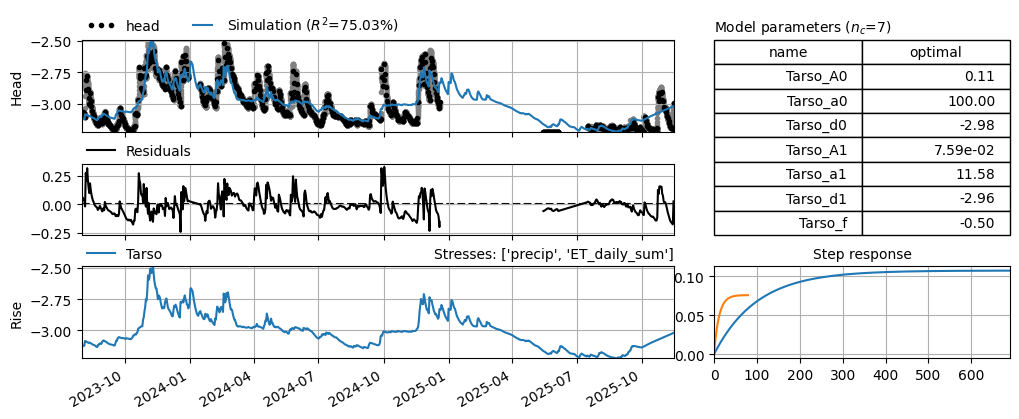

In [11]:
# delete all the stressmodels, the constant and the transform
ml.del_stressmodel("recharge")
ml.del_constant()
#ml.del_transform()

# then add a TarsoModel
sm = ps.TarsoModel(prec, df_evap_mak_daily, dmin=head.min(), dmax=head.max(), name="Tarso")
ml.add_stressmodel(sm)

#--- Constrain time scales & evap factor --------------------------------------
ml.set_parameter("Tarso_a0", pmin=0,    pmax=100.0)   # days
ml.set_parameter("Tarso_a1", pmin=10.0, pmax=100.0)   # days

# --- Define calibration period -----------------------------------------------
tmin_cal = "2023-08-01"   # <-- set your own start date
tmax_cal = "2025-11-15"   # <-- set your own end date

# Solve only over calibration period
#ml.solve(warmup=3650,tmin=tmin_cal, tmax=tmax_cal, report=True)
ml.solve(warmup=3650, report=True)

# Plot results (by default over full period, or restrict via tmin/tmax if you want)
ml.plots.results(tmin=tmin_cal, tmax=tmax_cal, figsize=(10, 4))

# Saving model to file
ml.to_file(name_model + "_tarso_model.pas")

In [12]:
ml.get_parameters()

array([ 1.07367017e-01,  1.00000000e+02, -2.98377688e+00,  7.58875618e-02,
        1.15774509e+01, -2.96428329e+00, -5.04872116e-01])

In [13]:
ml.get_response_tmax("Tarso", cutoff=0.95)

np.float64(299.573227355229)

In [14]:
# Functie om karakterestieken van de block response te krijgen
def get_peakblock_t95(param):
    """
    Computes peak block and characteristic response time (t95) for
    an exponential model with given parameters.

    Parameters:
        param (dict): Dictionary containing model parameters.

    Returns:
        tuple: (Piek_e, t95_e, Piek_0, t95_0) - peak block and t95 for both upper (_e) and lower regime (_0).
    """
    A1, a1, A0, a0, d0, d1 = (
        param["Tarso_A1"],
        param["Tarso_a1"],
        param["Tarso_A0"],
        param["Tarso_a0"],
        param["Tarso_d0"],
        param["Tarso_d1"],
    )

    # Compute equivalent parameters
    A_e = 1 / ((1 / A0) + (1 / A1))
    (A1 / (A0 + A1)) * d0 + (A0 / (A0 + A1)) * d1
    a_e = (a1 / A1) * A_e

    # Compute characteristic response times
    t95_e = ps.Exponential().get_tmax(p=(A_e, a_e), cutoff=0.95)
    t95_0 = ps.Exponential().get_tmax(p=(A0, a0), cutoff=0.95)

    # Compute peak blocks
    Piek_e = ps.Exponential(meanstress=1, cutoff=0.95).block((A_e, a_e))[0]
    Piek_0 = ps.Exponential(meanstress=1, cutoff=0.95).block((A0, a0))[0]

    return Piek_e, t95_e, Piek_0, t95_0

In [15]:
# --- Map ml.get_parameters() -> your dict format
vals = ml.get_parameters()  # array([A0, a0, d0, A1, a1, d1, f])

param = {
    "Tarso_A0": float(vals[0]),
    "Tarso_a0": float(vals[1]),
    "Tarso_d0": float(vals[2]),
    "Tarso_A1": float(vals[3]),
    "Tarso_a1": float(vals[4]),
    "Tarso_d1": float(vals[5]),
    # not used by your function, but available:
    "Tarso_f":  float(vals[6]),
}

# --- Now call your function
Piek_e, t95_e, Piek_0, t95_0 = get_peakblock_t95(param)

print(f"Peak block (equivalent): {Piek_e:.6g}")
print(f"t95 (equivalent):        {t95_e:.2f} days")
print(f"Peak block (A0,a0):      {Piek_0:.6g}")
print(f"t95 (A0,a0):             {t95_0:.2f} days")

Peak block (equivalent): 0.0060945
t95 (equivalent):        20.32 days
Peak block (A0,a0):      0.00106832
t95 (A0,a0):             299.57 days


In [16]:
ml.get_response_tmax("Tarso", cutoff=0.95)

np.float64(299.573227355229)

In [17]:
# Overall time span (days)
span_days = (df_head.index.max() - df_head.index.min()) / pd.Timedelta(days=1)
print("Total span (days):", span_days)

Total span (days): 1037.5416666666667
